# **UYARI / EKSTRA ANALİZ NOTU**

Bu dosya, dersin ana gereksinimi olan **2×3 repeated-measures (RM) ANOVA** analizinin yerine geçmez.  
Bu kod, proje sürecinde alternatif bir yaklaşımı denemek ve ek gözlemler elde etmek amacıyla hazırlanmış **“ekstra/keşifsel”** bir çalışmadır.

## **Kapsam**
- Bu dosyada, **katılımcı cinsiyeti (participant_gender)** analize dahil edilerek **2×2×3** yapıya genişletilmiş bir analiz denenmiştir.  
- Ders kapsamında beklenen ana raporlama, ayrı bir ana kod dosyasında **2×3 RM-ANOVA** ile yapılmıştır.

## **Önemli notlar**
- Bu dosyadaki sonuçlar **keşifsel** niteliktedir ve ana raporun temel bulgularını desteklemek amacıyla **“ek”** olarak kullanılmalıdır.
- Bazı bölümlerde, yazılım/uygulama kısıtları nedeniyle **RM-ANOVA yerine OLS + katılımcı sabit etkileri (C(participant))** gibi pratik çözümler denenmiştir. Bu yaklaşımın varsayımları ve kapsamı, ana analiz dosyasındaki yöntemden farklı olabilir.
- Bu nedenle, burada üretilen p-değerleri ve yorumlar **nihai sonuç** olarak değil; **yöntem denemesi ve ek kontrol** amacıyla değerlendirilmelidir.
- Rapor 4 çok uzun olduğu için bu kısımda ulaştığımız sonuçlar Rapor-4 te yer almadı.

# Part 1: Loading Libraries and Checking Data

In [1]:
# Block 1: Data Loading and Imports Libraries

import pandas as pd
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm


# Load the processed summary data
# Her katılımcı için 6 koşulun (2 Cinsiyet x 3 Duygu) ortalamasını içeren dosya
input_file = "processed_data/final_summary_for_anova.csv"
df_summary = pd.read_csv(input_file)

print("Data loaded successfully for statistical testing.")
print(f"Number of participants in analysis: {df_summary['participant'].nunique()}")

Data loaded successfully for statistical testing.
Number of participants in analysis: 18


In [2]:
# Blok 2: Column naming update
# Veri setindeki gender isimlendirmesi karışık olduğu için düzeltmek gerekiyordu.
df_summary = df_summary.rename(columns={
    'Gender': 'face_gender',
    'gender': 'participant_gender'
})

print("Yeni Sütun İsimleri:", df_summary.columns.tolist())

Yeni Sütun İsimleri: ['participant', 'face_gender', 'Emotion', 'accuracy', 'mean_rt', 'participant_gender', 'age', 'handedness']


**NOT: Gender-gender karmaşıklığını yukarıdaki kodla giderdik.**

In [3]:
# Block 3: 

# Duyguları valansı(duygu yükü) esas alarak sırlıyoruz. Verinin eksik olup olmadığını kontrol ediyoruz.

# Basic sanity checks
emotion_order = ['Angry', 'Neutral', 'Happy']
gender_order = ['Female', 'Male']  # only for consistent display

df_summary['Emotion'] = pd.Categorical(df_summary['Emotion'], categories=emotion_order, ordered=True)
df_summary['face_gender'] = pd.Categorical(df_summary['face_gender'], categories=gender_order, ordered=True)

# Each participant should have 6 rows (2*3)
counts = df_summary.groupby('participant').size()
print("Participants:", df_summary['participant'].nunique())
print("Rows per participant (should all be 6):")
print(counts.value_counts().sort_index())

# Check missing cells
print("\nMissing accuracy cells:", df_summary['accuracy'].isna().sum())


Participants: 18
Rows per participant (should all be 6):
6    18
Name: count, dtype: int64

Missing accuracy cells: 0


In [4]:
# Block 4: Katılımcı Demografisi ve Örneklem Özeti
# Bu blok, analize dahil edilen katılımcıların demografik dağılımını (cinsiyet, el kullanımı, yaş) özetlemek amacıyla oluşturulmuştur.

print("=== Katılımcı Demografik Özeti ===")

# Her katılımcı için 6 satır veri bulunduğundan, tekrar eden kayıtları önlemek için katılımcı bazlı tekilleştirme yapılır.
participant_demographics = df_summary.drop_duplicates(subset=['participant'])

# 1. Toplam Katılımcı Sayısı
total_n = len(participant_demographics)
print(f"Toplam Katılımcı Sayısı (N): {total_n}")

# 2. Cinsiyet Dağılımı
# 'participant_gender' sütunu üzerinden hesaplanır.
p_gender_counts = participant_demographics['participant_gender'].value_counts()
print("\nKatılımcı Cinsiyet Dağılımı:")
for gender, count in p_gender_counts.items():
    percentage = (count / total_n) * 100
    print(f"- {gender}: {count} kişi (%{percentage:.1f})")

# 3. El Kullanımı (Handedness) Dağılımı
p_hand_counts = participant_demographics['handedness'].value_counts()
print("\nEl Kullanımı (Handedness) Dağılımı:")
for hand, count in p_hand_counts.items():
    percentage = (count / total_n) * 100
    print(f"- {hand}: {count} kişi (%{percentage:.1f})")

# 4. Yaş İstatistiği (Eğer veri setinde mevcutsa)
if 'age' in participant_demographics.columns:
    mean_age = participant_demographics['age'].mean()
    std_age = participant_demographics['age'].std()
    min_age = participant_demographics['age'].min()
    max_age = participant_demographics['age'].max()
    print(f"\nYaş İstatistikleri: Ortalama = {mean_age:.2f} (SS = {std_age:.2f}), Aralık: {min_age}-{max_age}")

print("==================================")

=== Katılımcı Demografik Özeti ===
Toplam Katılımcı Sayısı (N): 18

Katılımcı Cinsiyet Dağılımı:
- Female: 10 kişi (%55.6)
- Male: 8 kişi (%44.4)

El Kullanımı (Handedness) Dağılımı:
- Right: 16 kişi (%88.9)
- Left: 2 kişi (%11.1)

Yaş İstatistikleri: Ortalama = 25.33 (SS = 7.83), Aralık: 22-50


**Yukarıdaki bilgiler doğrultusunda verileri cinsiyete göre incelemenin mümkün olduğunu(10 kadın ve 8 erkek, dengeli), ancak sağlaklık-solaklık açısından incelemenin mantıklı olmadığını söyleyebiliriz(16 sağlak ve 2 solak, dengesiz dağılım).**

**Ayrıca yaş dağılımının homojen olmamasından dolayı(çok ciddi bir çoğunluk genç) araştırmamıza yaşla ilgili ilişkileri dahil etmedik.**

# Part 2: Checking Normal Distribution Analysis

In [5]:
# Block 5: Varsayım Kontrolleri - Normal Dağılım Analizi (Skewness & Kurtosis)
# Shapiro-Wilk çok katı olduğu için, literatürde yaygın kabul gören Çarpıklık (Skewness) ve Basıklık (Kurtosis) değerlerini inceliyoruz.



print("=== Dağılım Analizi: Skewness ve Kurtosis (Normallik Kontrolü) ===")

dependent_vars = ['accuracy', 'mean_rt']
distribution_results = []

for var in dependent_vars:
    for g in df_summary['face_gender'].unique():
        for e in df_summary['Emotion'].unique():
            group_data = df_summary[(df_summary['face_gender'] == g) & (df_summary['Emotion'] == e)][var]
            
            # Skewness ve Kurtosis hesaplanır
            s = skew(group_data)
            k = kurtosis(group_data) # Fisher’s definition (normal = 0)
            
            # Yaygın akademik kriter: Değerler -2 ile +2 arasındaysa "Normal" kabul edilir.
            is_acceptable = (-2 < s < 2) and (-2 < k < 2)
            
            distribution_results.append({
                'Variable': var,
                'Face_Gender': g,
                'Emotion': e,
                'Skewness': round(s, 3),
                'Kurtosis': round(k, 3),
                'Acceptable_Normal': is_acceptable
            })

# Sonuçları tablo formatında görelim
df_dist = pd.DataFrame(distribution_results)
display(df_dist)

# Özet yorum
failed_dist = df_dist[df_dist['Acceptable_Normal'] == False]
if failed_dist.empty:
    print("\nTüm koşullarda Skewness/Kurtosis değerleri -2 ile +2 arasındadır. Veri yaklaşık normal dağılım sergilemektedir.")
else:
    print(f"\nDikkat: {len(failed_dist)} hücrede değerler hedeflenen aralığın dışındadır.")

=== Dağılım Analizi: Skewness ve Kurtosis (Normallik Kontrolü) ===


,Variable,Face_Gender,Emotion,Skewness,Kurtosis,Acceptable_Normal
0,accuracy,Female,Angry,-0.332,-0.637,True
1,accuracy,Female,Happy,-0.270,-1.117,True
2,accuracy,Female,Neutral,-0.720,-0.443,True
3,accuracy,Male,Angry,-0.928,-0.874,True
4,accuracy,Male,Happy,-1.716,2.562,False
5,accuracy,Male,Neutral,-0.180,-0.974,True
6,mean_rt,Female,Angry,1.332,2.331,False
7,mean_rt,Female,Happy,2.161,5.189,False
8,mean_rt,Female,Neutral,2.210,4.974,False
9,mean_rt,Male,Angry,0.912,0.309,True



Dikkat: 4 hücrede değerler hedeflenen aralığın dışındadır.


**Yukarıdaki tabloya göre accuracy/rt(2) * face_gender(2) * emotion(3)= 12 veri grubunun 8 tanesi normal dağılıma yakın bir dağılım sergilerken 4 tanesinde belirgin sapmalar gözlemlenmektedir. Özellikle accuracy değişkeninin 0–1 aralığında sınırlı olması ve bazı koşullarda performansın yüksek seyretmesi nedeniyle (tavan etkisi), bu hücrelerde dağılımın ideal normal formdan uzaklaşması beklenen bir durumdur. RT tarafında gözlenen sapmalar ise tepki sürelerinin doğası gereği sağa çarpık dağılım gösterebilmesiyle açıklanabilir.**

**ANOVA bu tür sapmalara karşı dayanıklı olduğu için sapmalara rağmen analiz kısmına geçiyoruz.**

# Part 3: RT Analysis with Mixed-Design ANOVA

**Katılımcı yüzünü de hesaba katmamız gerekince 2 * 2 * 3 lük bir durumla karşılaşıyoruz. Bu yüzden aşağıda reaksiyon süresi ver doğruluk için "Mixed-Design ANOVA" metodunu kullandık.**

**Bu yüzden analizimizin bu aşamasında, sadece uyaran özelliklerini değil, katılımcıların bireysel demografik değişkenlerini de sürece dahil eden "Mixed-Design ANOVA" kullandık. Bu seviye analiz tekniği, katılımcı bazlı varyasyonu kontrol altında tutarak daha hassas sonuçlar elde etmemizi sağlar.**

In [6]:
# Block 6: Mixed-design ANOVA for Reaction Time (RT)
# DV: mean_rt
# Between-subject: participant_gender
# Within-subject:  face_gender, Emotion
# LMM yerine OLS + Subject Fixed Effects kullanılır



print("=== MIXED ANOVA Results: REACTION TIME (RT) ===")

df_rt = df_summary.copy()

# Kategorik değişkenleri belirtiyoruz
for c in ["participant", "participant_gender", "face_gender", "Emotion"]:
    df_rt[c] = df_rt[c].astype("category")

# Mixed-design ANOVA (subject fixed effects ile)
model_rt = smf.ols(
    "mean_rt ~ C(participant_gender) * C(face_gender) * C(Emotion) + C(participant)",
    data=df_rt
).fit()

# ANOVA tablosu
aov_rt = anova_lm(model_rt, typ=2)
print(aov_rt)

# p-değerlerini sade bir tabloya alıyoruz
rt_pvals = aov_rt[["PR(>F)"]].rename(columns={"PR(>F)": "p_value"})
rt_pvals["p_value_fixed"] = rt_pvals["p_value"].apply(lambda x: f"{x:.5f}")
rt_pvals["Significant"] = rt_pvals["p_value"] < 0.05
display(rt_pvals[["p_value_fixed", "Significant"]])


=== MIXED ANOVA Results: REACTION TIME (RT) ===
                                                   sum_sq    df          F  \
C(participant_gender)                            0.019765   1.0   1.150603   
C(face_gender)                                   0.212851   1.0  12.390638   
C(Emotion)                                       0.040548   2.0   1.180206   
C(participant)                                   7.028299  17.0  24.066864   
C(participant_gender):C(face_gender)             0.023814   1.0   1.386286   
C(participant_gender):C(Emotion)                 0.015995   2.0   0.465566   
C(face_gender):C(Emotion)                        0.021735   2.0   0.632618   
C(participant_gender):C(face_gender):C(Emotion)  0.020390   2.0   0.593492   
Residual                                         1.374269  80.0        NaN   

                                                       PR(>F)  
C(participant_gender)                            2.866481e-01  
C(face_gender)                             

,p_value_fixed,Significant
C(participant_gender),0.28665,False
C(face_gender),0.00072,True
C(Emotion),0.31251,False
C(participant),0.00000,True
C(participant_gender):C(face_gender),0.24252,False
C(participant_gender):C(Emotion),0.62947,False
C(face_gender):C(Emotion),0.53384,False
C(participant_gender):C(face_gender):C(Emotion),0.55481,False
Residual,nan,False


**Yukarıdaki tablo reaksiyon süresi (RT) için katılımcı cinsiyetini (participant_gender) between-subject faktör, yüzün cinsiyetini (face_gender) ve yüz ifadesindeki duyguyu (Emotion) within-subject faktörler olarak ele alan mixed-design ANOVA sonuçlarını göstermektedir.**

**Tablodan anlaşılabileceği gibi, reaksiyon süresi açısından genel olarak anlamlı bir etki oldukça sınırlıdır. Katılımcı cinsiyeti, yüz ifadesindeki duygu ve bu değişkenlerin birbirleriyle olan etkileşimlerinin hiçbirinde anlamlı bir fark gözlemlenmemiştir. Bu durum, tepki süresinin büyük ölçüde bu faktörlerin kombinasyonlarından bağımsız olduğunu göstermektedir. RT’de anlamlı etkileşim bulunmadığı için simple main effects analizine gidilmemiştir.”**

**Bununla birlikte, yüzün cinsiyeti (C(face_gender), p = 0.00072) reaksiyon süresi üzerinde tek başına anlamlı bir ana etkiye sahiptir. Bu etkinin yönünü görmek için aşağıda bir grafik oluşturuyoruz.**

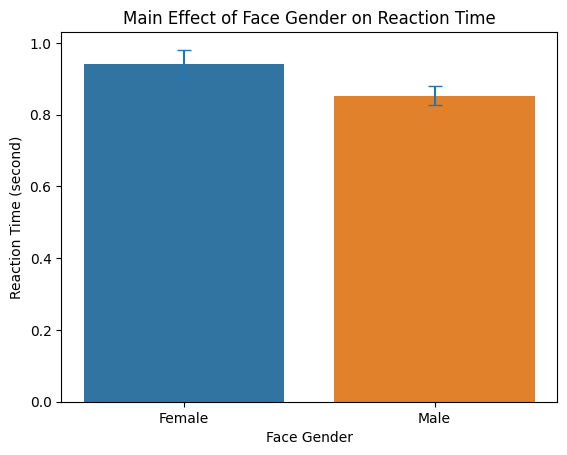

In [7]:
# Block 7: RT Main Effect Visualization: Face Gender

df_rt_main = (
    df_summary
    .groupby("face_gender", as_index=False, observed=False)
    .agg(mean_rt=("mean_rt", "mean"),
         sem_rt=("mean_rt", "sem"))
)

plt.figure()
sns.barplot(
    data=df_rt_main,
    x="face_gender",
    y="mean_rt",
    hue="face_gender",              
    palette={"Female": "tab:blue", "Male": "tab:orange"},
    legend=False,                  
    errorbar=None
)

plt.errorbar(
    x=range(len(df_rt_main)),
    y=df_rt_main["mean_rt"],
    yerr=df_rt_main["sem_rt"],
    fmt="none",
    capsize=5
)

plt.ylabel("Reaction Time (second)")
plt.xlabel("Face Gender")
plt.title("Main Effect of Face Gender on Reaction Time")
plt.show()


**Yukarıdaki grafikte görüldüğü üzere kadın yüzlerini tanımanın erkek yüzlerini tanımaya göre daha hızlı gerçekleştiğini söyleyebiliriz. Bu grafik, Part 3’te raporlanan C(face_gender) ana etkisinin yönünü göstermektedir.**

# Part 4: Accuracy Analysis with Mixed-Design ANOVA

In [8]:
# Block 8: Mixed-design ANOVA (Accuracy)
# statsmodels AnovaRM between desteklemediği için: OLS + subject fixed effects (C(participant)) + factorial design kullanacağız
# Between-subject: participant_gender
# Within-subject:  face_gender, Emotion
# DV: accuracy  (df_summary: participant × condition ortalamaları)


print("=== MIXED ANOVA (OLS+Subject FE) Results: ACCURACY ===")

df_acc = df_summary.copy()

# Kategorik tipler (önemli)
for c in ["participant", "participant_gender", "face_gender", "Emotion"]:
    df_acc[c] = df_acc[c].astype("category")

# Subject fixed effects ile mixed ANOVA pratik eşdeğeri

model = smf.ols(
    "accuracy ~ C(participant_gender) * C(face_gender) * C(Emotion) + C(participant)",
    data=df_acc
).fit()

# Dengeli tasarımda typ=2 genelde yeterli.
aov = anova_lm(model, typ=2)
print(aov)

out = aov[["PR(>F)"]].rename(columns={"PR(>F)": "p_value"})
out["p_value_fixed"] = out["p_value"].apply(lambda x: f"{x:.8f}")
out["Significant"] = out["p_value"] < 0.05
display(out[["p_value_fixed", "Significant"]])


=== MIXED ANOVA (OLS+Subject FE) Results: ACCURACY ===
                                                   sum_sq    df          F  \
C(participant_gender)                            0.034487   1.0  10.125814   
C(face_gender)                                   0.003004   1.0   0.881922   
C(Emotion)                                       0.060141   2.0   8.829029   
C(participant)                                   1.548921  17.0  26.751969   
C(participant_gender):C(face_gender)             0.000432   1.0   0.126727   
C(participant_gender):C(Emotion)                 0.009688   2.0   1.422215   
C(face_gender):C(Emotion)                        0.144046   2.0  21.146911   
C(participant_gender):C(face_gender):C(Emotion)  0.005630   2.0   0.826540   
Residual                                         0.272467  80.0        NaN   

                                                       PR(>F)  
C(participant_gender)                            2.082241e-03  
C(face_gender)                      

,p_value_fixed,Significant
C(participant_gender),0.00208224,True
C(face_gender),0.35050249,False
C(Emotion),0.00034299,True
C(participant),0.00000000,True
C(participant_gender):C(face_gender),0.72278754,False
C(participant_gender):C(Emotion),0.24721056,False
C(face_gender):C(Emotion),0.00000004,True
C(participant_gender):C(face_gender):C(Emotion),0.44126218,False
Residual,nan,False


**Not: Bu modelde within faktörlerin ana etkileri, C(participant) yüzünden tam olarak ayrı raporlanmayabilir; ancak ETKİLEŞİMLER (örn. participant_gender:Emotion) düzgün test edilir. Mixed-design'da asıl ilgi genelde bu etkileşimlerdir.**

.

**Yukarıdaki tablodaki bulgular çalışmamız için çok kritiktir. Önemli gözlemleri şu şekilde sıralayabiliriz:**

**-> C(Emotion) (p = 0.00034): Duygusal ifade doğruluk üzerinde tek başına anlamlı bir etkiye sahiptir.**
**Bu sonuç, yüz ifadesinin (Mutlu, Nötr, Kızgın) cinsiyet tanıma doğruluğunu etkilediğini göstermektedir. Katılımcılar bazı duygusal ifadelerde diğerlerine kıyasla daha isabetli kararlar vermiştir. Bu etkileşimin detayı aşağıda tablo olarak gösterilip yorumlanmıştır.**

**-> C(participant_gender) (p = 0.002): Katılımcının cinsiyeti doğruluk üzerinde genel bir etkiye sahiptir.**
**Bu bulgu, kadın ve erkek katılımcılar arasında genel doğruluk düzeyinde bir fark olduğunu göstermektedir. Ancak bu etki, yüz cinsiyeti veya duygu ile etkileşime girmemektedir; yani katılımcı cinsiyeti, belirli duygu veya yüz türlerine özgü bir işlemleme stratejisi farkına işaret etmemektedir. Bu etkileşimin de detayı aşağıda tablo olarak gösterilip yorumlanmıştır.**

**-> C(face_gender):C(Emotion) (p < 0.001): Burası en kritik bulgudur. Yüzün cinsiyeti ile duygu durumu arasında çok güçlü bir etkileşim (interaction) vardır.**
**Bu etkileşim, duygusal ifadenin doğruluk üzerindeki etkisinin yüzün cinsiyetine bağlı olarak değiştiğini göstermektedir. Başka bir deyişle, aynı duygu ifadesi kadın ve erkek yüzlerde cinsiyet tanıma performansını farklı biçimde etkilemektedir (örneğin, kızgınlık ifadesi kadın yüzlerde doğruluğu daha fazla düşürürken erkek yüzlerde aynı etkiyi yaratmayabilir).**
**C(face_gender):C(Emotion) etkileşimini ayrıntılandırmak için Part 5'te simple main effects analysis uyguluyoruz.**



,Emotion,mean_accuracy,sem_accuracy
0,Angry,0.900299,0.013403
1,Neutral,0.925233,0.012058
2,Happy,0.957927,0.007941


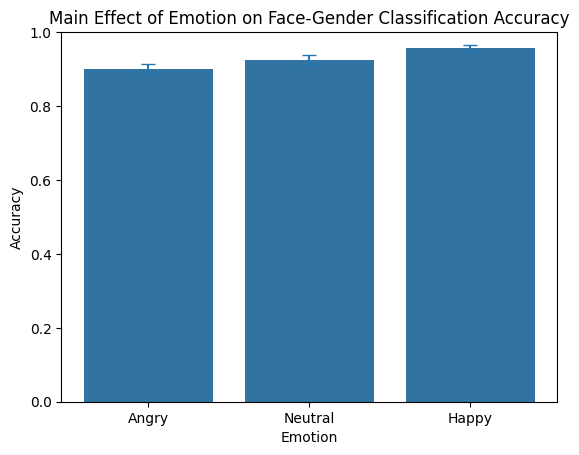

In [9]:
# Block 9: Main Effect Visualization: Emotion on Accuracy 


# Emotion'a göre ortalama accuracy
df_acc_emotion = (
    df_summary
    .groupby("Emotion", as_index=False, observed=False)
    .agg(mean_accuracy=("accuracy", "mean"),
         sem_accuracy=("accuracy", "sem"))
)

# Tabloyu görmek için
display(df_acc_emotion)

# Grafik
plt.figure()
sns.barplot(
    data=df_acc_emotion,
    x="Emotion",
    y="mean_accuracy",
    errorbar=None
)

# SEM hata çubukları
plt.errorbar(
    x=range(len(df_acc_emotion)),
    y=df_acc_emotion["mean_accuracy"],
    yerr=df_acc_emotion["sem_accuracy"],
    fmt="none",
    capsize=5
)

plt.xlabel("Emotion")
plt.ylabel("Accuracy")
plt.title("Main Effect of Emotion on Face-Gender Classification Accuracy")
plt.ylim(0, 1)
plt.show()


**Yukarıdaki tablo ve grafik, duygusal ifadenin yüz cinsiyeti tanıma doğruluğu (accuracy) üzerinde anlamlı bir ana etkiye sahip olduğunu göstermektedir. Görüldüğü üzere doğruluk oranı en düşük Kızgın yüzlerde, daha yüksek Nötr yüzlerde ve en yüksek Mutlu yüzlerde elde edilmiştir. Bu örüntü, katılımcıların duygusal ifadesi daha olumlu olan yüzlerde cinsiyet tanıma görevini daha isabetli biçimde yerine getirdiğini göstermektedir.**

**Bu bulgu, Part 4’te raporlanan C(Emotion) ana etkisinin (p = 0.00034) yönünü açıkça ortaya koymakta ve duygusal ifadenin yüz tanıma doğruluğunu sistematik biçimde etkilediğini desteklemektedir. Ancak bu ana etki, aşağıda ele alınan C(face_gender) × C(Emotion) etkileşimi göz önünde bulundurularak değerlendirilmelidir; zira duygunun doğruluk üzerindeki etkisi, yüzün cinsiyetine bağlı olarak farklılaşabilmektedir.**

,participant_gender,mean_accuracy,sem_accuracy
0,Female,0.929342,0.008820
1,Male,0.925917,0.011009


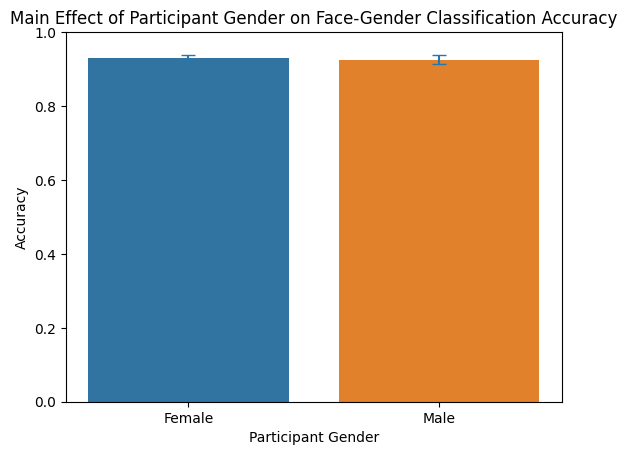

In [10]:
# Block 10: Main Effect Visualization: Participant Gender on Accuracy 


# participant_gender'a göre ortalama accuracy
df_acc_pg = (
    df_summary
    .groupby("participant_gender", as_index=False, observed=False)
    .agg(mean_accuracy=("accuracy", "mean"),
         sem_accuracy=("accuracy", "sem"))
)

# Tabloyu görmek için
display(df_acc_pg)

# Grafik
plt.figure()
sns.barplot(
    data=df_acc_pg,
    x="participant_gender",
    y="mean_accuracy",
    hue="participant_gender",                 
    palette={"Female": "tab:blue", "Male": "tab:orange"},
    legend=False,
    errorbar=None
)

# SEM hata çubukları
plt.errorbar(
    x=range(len(df_acc_pg)),
    y=df_acc_pg["mean_accuracy"],
    yerr=df_acc_pg["sem_accuracy"],
    fmt="none",
    capsize=5
)

plt.xlabel("Participant Gender")
plt.ylabel("Accuracy")
plt.title("Main Effect of Participant Gender on Face-Gender Classification Accuracy")
plt.ylim(0, 1)
plt.show()


**Yukarıdaki grafik, katılımcı cinsiyetine göre ortalama doğruluk (accuracy) değerlerinin birbirine oldukça yakın olduğunu göstermektedir. Görsel olarak fark sınırlı görünse de, mixed-design ANOVA sonuçları katılımcı cinsiyetinin doğruluk üzerinde istatistiksel olarak anlamlı bir ana etkiye sahip olduğunu ortaya koymaktadır. Bu durum, katılımcı cinsiyetine bağlı farkın mutlak büyüklüğünün küçük olmasına karşın, farklı koşullar boyunca tutarlı biçimde ortaya çıkması nedeniyle istatistiksel olarak anlamlı hale geldiğini düşündürmektedir. Bununla birlikte, bu ana etki yüz cinsiyeti veya duygusal ifade ile etkileşime girmemekte; dolayısıyla katılımcı cinsiyeti, belirli yüz türlerine veya duygulara özgü bir işlemleme stratejisi farkına işaret etmemektedir.**

# Part 5: Accuracy Analysis with Simple Main Effects Analysis

**Bu analizler, Part 4’te saptanan face_gender × Emotion etkileşimini ayrıntılandırmak amacıyla yapılmıştır.**

In [11]:
# Block 11: Simple Main Effects Analysis for ACCURACY 

print("=== Simple Main Effects: Accuracy (Deep Analysis) ===")

# --- 1. YÖN: Her duygu içinde yüz cinsiyetlerini karşılaştıralım ---
m_vs_f_list = []
for emotion in df_summary['Emotion'].unique():
    subset = df_summary[df_summary['Emotion'] == emotion]
    res = pg.pairwise_tests(data=subset, dv='accuracy', within='face_gender', 
                            subject='participant', padjust='bonferroni')
    res['Emotion_Group'] = emotion
    if 'p-corr' not in res.columns:
        res['p-corr'] = res['p-unc']
    m_vs_f_list.append(res)

m_vs_f_final = pd.concat(m_vs_f_list)

print("\n1. Duygu Grupları İçinde Yüz Cinsiyeti Karşılaştırması:")
# Formatlama: p değerlerini virgülden sonra 6 basamağa sabitliyoruz
m_vs_f_final['p-unc'] = m_vs_f_final['p-unc'].apply(lambda x: f"{x:.6f}")
m_vs_f_final['p-corr'] = m_vs_f_final['p-corr'].apply(lambda x: f"{x:.6f}")

m_vs_f_display = m_vs_f_final[['Emotion_Group', 'A', 'B', 'p-unc', 'p-corr', 'hedges']]
display(m_vs_f_display)


# --- 2. YÖN: Her yüz cinsiyeti içinde duyguları karşılaştıralım ---
emotion_diff_list = []
for f_gender in df_summary['face_gender'].unique():
    subset = df_summary[df_summary['face_gender'] == f_gender]
    res = pg.pairwise_tests(data=subset, dv='accuracy', within='Emotion', 
                            subject='participant', padjust='bonferroni')
    res['Face_Gender_Group'] = f_gender
    if 'p-corr' not in res.columns:
        res['p-corr'] = res['p-unc']
    emotion_diff_list.append(res)

emotion_final = pd.concat(emotion_diff_list)

print("\n2. Yüz Cinsiyeti İçinde Duyguların Karşılaştırması:")
# Formatlama: p değerlerini virgülden sonra 8 basamağa sabitliyoruz
emotion_final['p-unc'] = emotion_final['p-unc'].apply(lambda x: f"{x:.8f}")
emotion_final['p-corr'] = emotion_final['p-corr'].apply(lambda x: f"{x:.8f}")

emotion_display = emotion_final[['Face_Gender_Group', 'A', 'B', 'p-unc', 'p-corr', 'hedges']]
display(emotion_display)

=== Simple Main Effects: Accuracy (Deep Analysis) ===

1. Duygu Grupları İçinde Yüz Cinsiyeti Karşılaştırması:


,Emotion_Group,A,B,p-unc,p-corr,hedges
0,Angry,Female,Male,0.000208,0.000208,-1.704931
0,Happy,Female,Male,0.881819,0.881819,0.055222
0,Neutral,Female,Male,0.011048,0.011048,1.101261



2. Yüz Cinsiyeti İçinde Duyguların Karşılaştırması:


,Face_Gender_Group,A,B,p-unc,p-corr,hedges
0,Female,Angry,Neutral,0.00000713,0.00002139,-2.309478
1,Female,Angry,Happy,0.00000004,0.00000011,-2.367633
2,Female,Neutral,Happy,0.89205231,1.00000000,0.041581
0,Male,Angry,Neutral,0.00066816,0.00200449,0.848125
1,Male,Angry,Happy,0.86555677,1.00000000,-0.051976
2,Male,Neutral,Happy,0.00036713,0.00110139,-0.950915


**Önceki tablo gibi yukarıdaki tablo da araştırmamız için önemli çıktılar sunmaktadır:**

**-> Kızgın duygu durumunda, kadın ve erkek yüzleri arasında istatistiksel olarak çok güçlü ve anlamlı bir fark bulunmaktadır.**

**-> Nötr duygu durumunda, kadın ve erkek yüzleri arasındaki fark istatistiksel olarak anlamlı düzeydedir.**

**-> Kadın yüzleri özelinde, kızgınlık ifadesinin hem nötr hem de mutlu ifadelerle olan karşılaştırması istatistiksel olarak en yüksek düzeyde anlamlılık (en güçlü ilişki) göstermektedir.**

**-> Erkek yüzleri özelinde, kızgınlık ve nötr ifadeler arasındaki fark istatistiksel olarak anlamlı bir ilişkiye işaret etmektedir.**

**-> Erkek yüzlerinde, nötr ve mutlu ifadeler arasındaki fark istatistiksel olarak anlamlı düzeydedir.**

# Part 6: Visualization of Accuracy Analysis with Simple Main Effects Analysis

**Şimdi yukarıda bulduğumuz bu anlamlı ilişkilerin tam olarak neyi ifade ettiğini tablolar aracılığıyla kontrol ediyoruz.**

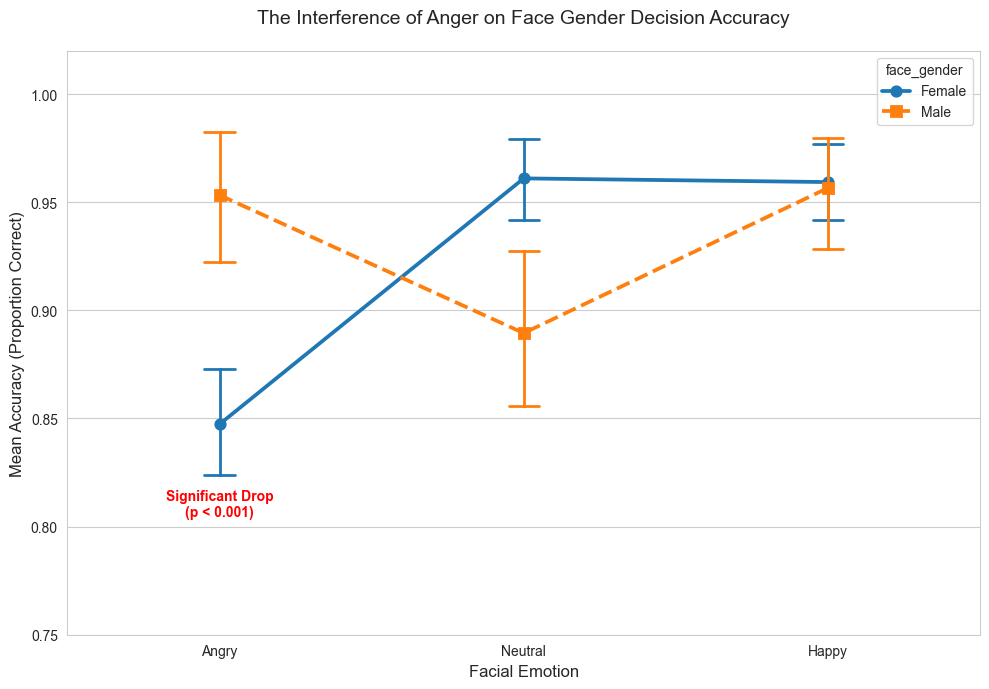

In [12]:
# Block 12: Hero Plot - Accuracy Interaction (Face Gender x Emotion)


plt.figure(figsize=(10, 7), dpi=100)
sns.set_style("whitegrid")

# Çizgi grafiği (Pointplot) etkileşimi göstermek için en iyisidir
ax = sns.pointplot(data=df_summary, x='Emotion', y='accuracy', hue='face_gender',
                   palette={'Female': '#1f77b4', 'Male': '#ff7f0e'},
                   markers=["o", "s"], linestyles=["-", "--"],
                   capsize=.1, err_kws={'linewidth': 2})

# Grafik detayları
plt.title('The Interference of Anger on Face Gender Decision Accuracy', fontsize=14, pad=20)
plt.ylabel('Mean Accuracy (Proportion Correct)', fontsize=12)
plt.xlabel('Facial Emotion', fontsize=12)
plt.ylim(0.75, 1.02) # Farkı vurgulamak için y eksenini daraltıyoruz.

# Anlamlılık notu ekleme 
plt.text(0, 0.805, "Significant Drop\n(p < 0.001)", color='red', fontweight='bold', ha='center')

plt.tight_layout()
plt.show()

**Önceki blokta bahsettiğimiz anlamlı ilişkileri yukarıdaki tabloyda detaylıca gözlemleyebiliriz:**

**-> Grafiğin "Angry" sütununa baktığımızda, mavi nokta (kadın) ile turuncu nokta (erkek) arasındaki dikey mesafe en uç noktadadır.  Yani kızgınlık, kadın yüzlerinde ciddi bir "isabet kaybına" yol açarken, erkek yüzlerinde başarıyı yüksek seviyelerde (0.95) tutmaktadır.**

**-> "Neutral" sütununda mavi noktanın turuncu noktanın üzerinde olduğunu görüyoruz. İstatistikteki anlamlı fark burada bir "yer değişimini" temsil etmektedir: Kadın yüzleri nötr durumdayken, erkeklerin nötr durumuna göre daha isabetli tanınmaktadır.**

**-> Mavi çizgiyi takip ettiğimizde, "Angry" noktasından "Neutral" ve "Happy" noktalarına doğru giden dik bir yokuş/yükseliş görmekteyiz. Bu görsel trend, p-değerindeki "en yüksek anlamlılık" sonucunun karşılığıdır: Kadın yüzleri için kızgınlık durumu, diğer iki duygudan tamamen kopuk ve çok daha düşük bir başarı seviyesindedir.**

**-> Turuncu (erkek) çizgiyi incelediğimizde, "Angry" noktasından "Neutral" noktasına doğru belirgin bir düşüş yaşandığını görüyoruz. İstatistiksel olarak saptadığın anlamlı ilişki burada şunu ifade eder: Katılımcılar erkek yüzlerini kızgınken, nötr oldukları duruma göre daha yüksek doğrulukla tanımaktadır. Kızgınlık, erkek cinsiyetinin teşhisini kolaylaştırmaktadır.**

**-> Turuncu çizginin grafikteki en alt noktası "Neutral" seviyesidir. "Neutral"dan "Happy"e geçişteki yükseliş, istatistiksel anlamlılığın yönünü gösterir: Erkek yüzlerini tanımada en çok zorlanılan (ve anlamlı derecede düşük başarı gösterilen) koşul nötr durumdur; mutlu yüzler bu performansı tekrar yukarı çekmektedir.**

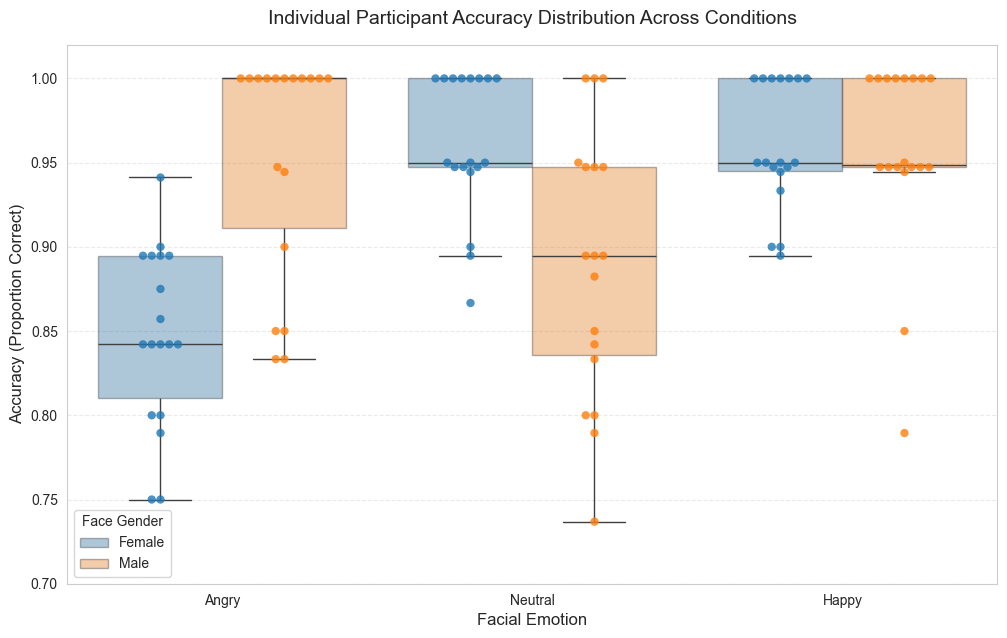

In [13]:
# Block 13: Distribution Plot - Boxplot with Individual Data Points
plt.figure(figsize=(12, 7), dpi=100) # Çözünürlüğü biraz artırdık

# Renk tutarlılığı için sözlük
consistent_palette = {'Female': '#1f77b4', 'Male': '#ff7f0e'}

# Boxplot: Kutuların içini daha iyi görmek için alpha (şeffaflık) ekledik
sns.boxplot(data=df_summary, x='Emotion', y='accuracy', hue='face_gender', 
            palette=consistent_palette, showfliers=False, 
            boxprops=dict(alpha=0.4)) # Kutuları hafif şeffaf yaptık ki noktalar parlasın

# Swarmplot: Her bir katılımcının noktasını tam üstüne koyar
# hue ve palette ekleyerek noktaların da kutu rengiyle aynı olmasını sağladık
sns.swarmplot(data=df_summary, x='Emotion', y='accuracy', hue='face_gender', 
              dodge=True, palette=consistent_palette, size=6, alpha=0.8)

# Gereksiz ikinci legend'ı (swarmplot'tan gelen) temizleyelim
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[0:2], labels[0:2], title='Face Gender', loc='lower left')

plt.title('Individual Participant Accuracy Distribution Across Conditions', fontsize=14, pad=15)
plt.ylabel('Accuracy (Proportion Correct)', fontsize=12)
plt.xlabel('Facial Emotion', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.ylim(0.7, 1.02) # 1.0'ın üzerindeki noktaların kesilmemesi için 1.02 yaptık

plt.show()

**Yukarıdaki Boxplot tablosundan şu gözlemleri yapmak mümkündür:**

**-> Çoğu koşulda noktaların 1.00 (tam isabet) çizgisinde yoğunlaştığı görülmektedir. Bu, deneyin genel olarak katılımcılar için kolay olduğunu ve verinin üst sınırda yığıldığını kanıtlar.**

**-> 'Angry-Female' koşulunda ise noktaların diğerlerine göre çok daha geniş bir alana yayıldığı ve kutunun belirgin şekilde aşağı kaydığı gözlenmektedir. Bu, kızgın kadın yüzlerini tanımanın sadece 'ortalama' bir zorluk olmadığını, hemen hemen tüm katılımcılar için bireysel düzeyde de bir zorluk yarattığını göstermektedir.**

**-> Erkek yüzlerinde (Turuncu kutular), kızgınlık durumunda varyansın (noktaların dağılımının) azaldığı ve başarının 1.00'e yaklaştığı; buna karşın nötr durumda noktaların aşağıya doğru sarktığı görülmektedir. Bu görsel kanıt, erkek yüzleri için kızgınlığın bir 'kolaylaştırıcı' olduğunu desteklemektedir.**

# Part 7: Checking Universality (Participation Gender Effects)

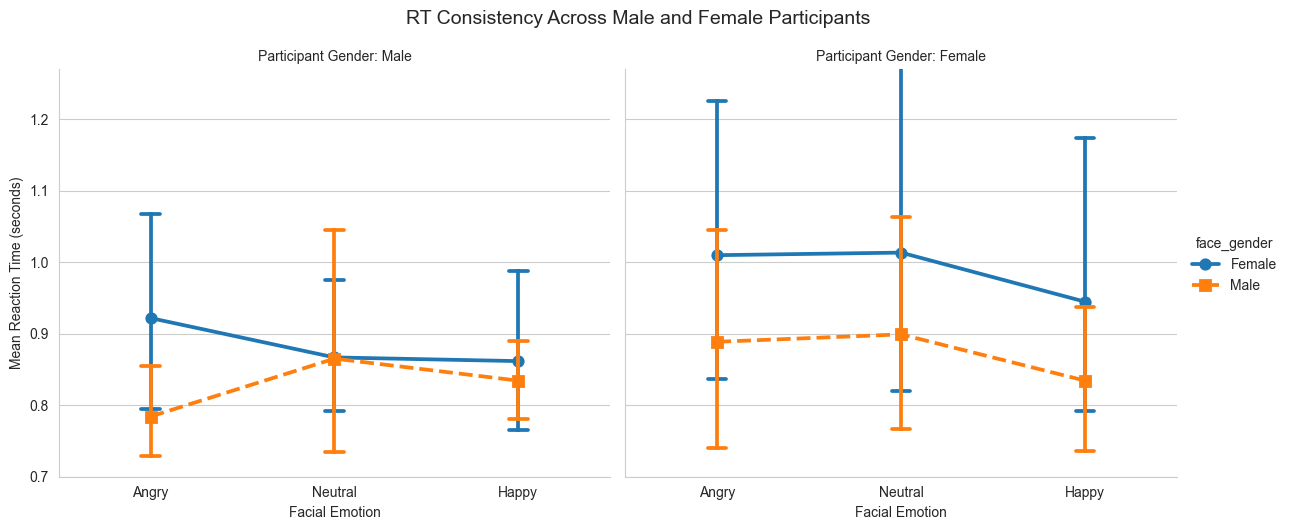

In [14]:
# Block 14: RT Universality Plot - Faceted by Participant Gender
# Renk tutarlılığı için önceki sözlüğü kullanıyoruz
consistent_palette = {'Female': '#1f77b4', 'Male': '#ff7f0e'}

g_rt = sns.catplot(
    data=df_summary, 
    x='Emotion', 
    y='mean_rt',                # Y eksenine hız verisini koyduk
    hue='face_gender', 
    col='participant_gender', 
    kind='point', 
    palette=consistent_palette, 
    markers=["o", "s"], 
    linestyles=["-", "--"],
    capsize=.1, 
    height=5, 
    aspect=1.2
)

# Eksen ve Başlık Düzenlemeleri
g_rt.set_axis_labels("Facial Emotion", "Mean Reaction Time (seconds)")
g_rt.set_titles("Participant Gender: {col_name}")
g_rt.fig.suptitle('RT Consistency Across Male and Female Participants', fontsize=14, y=1.05)

# RT değerlerine göre y eksenini ayarlıyoruz 
plt.ylim(0.7, 1.27) 

plt.show()

**Yukarıdaki her iki grafikte de (kadın ve erkek katılımcılar için) ortaya çıkan örüntünün büyük ölçüde benzer olduğunu görüyoruz. Her ne kadar nötr yüzler için grafikler arasında küçük farklılıklar gözlemlense de, Part 3'te bulduğumuz mixed-design ANOVA sonuçlarında katılımcı cinsiyetini içeren hiçbir etkileşimin (participant_gender × Emotion, participant_gender × face_gender ve üçlü etkileşim) anlamlı olmaması, katılımcı cinsiyetinin RT örüntüsünü sistematik olarak değiştirmediğini göstermektedir. Bu durum, tepki hızına ilişkin desenin her iki katılımcı grubunda da benzer şekilde ortaya çıktığına işaret etmektedir.**

**Her iki grafikte de mavi çizginin turuncu çizginin üzerinde konumlanması, erkek yüzlerinin kadın yüzlerine kıyasla daha hızlı tanındığını göstermektedir. Bu örüntünün hem kadın hem de erkek katılımcılarda aynı şekilde gözlemlenmesi, erkek yüzlerine yönelik hız avantajının katılımcı cinsiyetinden bağımsız olduğunu, yani bu etkinin evrensel bir özellik taşıdığını düşündürmektedir.**

**Özetle, yukarıdaki iki grafik yüz tanıma hızının (RT) yüzün cinsiyetine ve duygusal ifadeye bağlı örüntüsünün, katılımcı cinsiyetinden bağımsız olarak ortaya çıktığını; başka bir deyişle bu hız deseninin her iki katılımcı grubunda da benzer ve “evrensel” bir yapı sergilediğini göstermektedir.**

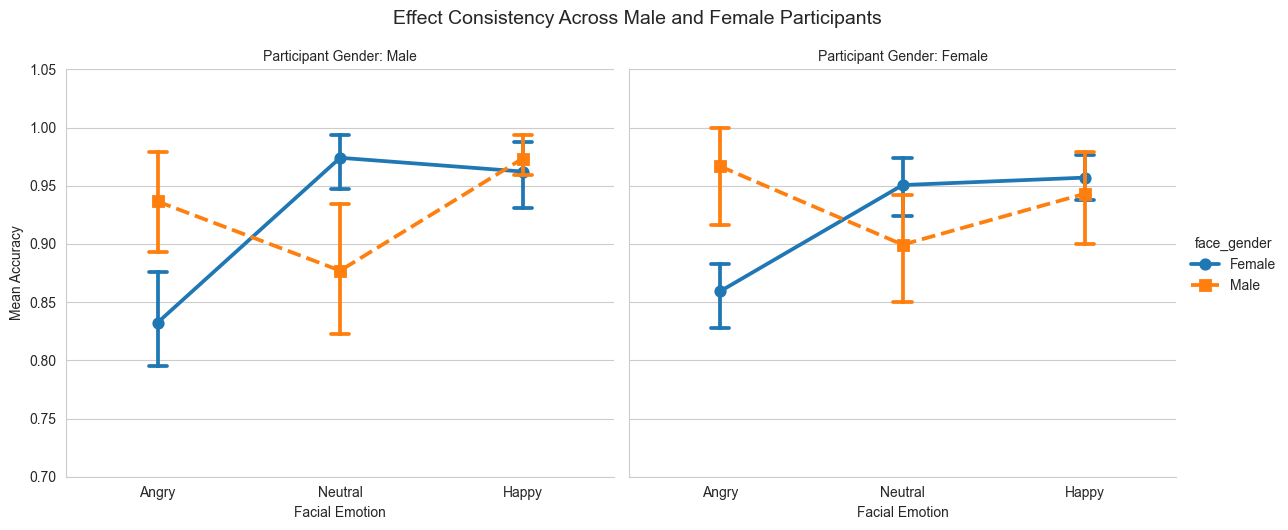

In [15]:
# Block 15: Accuracy Universality Plot - Faceted by Participant Gender
# Renkleri önceki grafiklerle (Mavi/Turuncu) eşlemek için sözlük tanımlıyoruz.
consistent_palette = {'Female': '#1f77b4', 'Male': '#ff7f0e'}

g = sns.catplot(
    data=df_summary, 
    x='Emotion', 
    y='accuracy', 
    hue='face_gender', 
    col='participant_gender', 
    kind='point', 
    palette=consistent_palette, # Sabit renk paleti uygulandı
    markers=["o", "s"],         # Kadın için daire, Erkek için kare marker
    linestyles=["-", "--"],      # Kadın için düz, Erkek için kesikli çizgi
    capsize=.1, 
    height=5, 
    aspect=1.2
)

# Eksen ve Başlık Düzenlemeleri
g.set_axis_labels("Facial Emotion", "Mean Accuracy")
g.set_titles("Participant Gender: {col_name}")
g.fig.suptitle('Effect Consistency Across Male and Female Participants', fontsize=14, y=1.05)
plt.ylim(0.7, 1.05)

plt.show()

**Yukarıdaki her iki grafikte de (erkek ve kadın katılımcılar için) çizgilerin oluşturduğu örüntünün neredeyse birebir olduğunu görüyoruz. Bu durum, katılımcı cinsiyetinin yüz tanımada doğruluğun (accuracy) hangi koşullarda artıp azaldığını belirleyen örüntüyle ilişkili olmadığını göstermektedir. Başka bir deyişle, katılımcı cinsiyeti doğruluk düzeyini genel olarak etkileyebilse de, yüz cinsiyeti ve duyguya bağlı doğruluk örüntüsü her iki grup için de aynıdır.**

**Bu bulgu, “Kızgın Kadın” dezavantajının ve “Kızgın Erkek” avantajının yalnızca belirli bir katılımcı grubuna özgü bir önyargı olmadığını; aksine hem kadın hem de erkek katılımcılarda benzer biçimde ortaya çıkan, genellenebilir bir bilişsel işlemleme örüntüsünü yansıttığını göstermektedir. Nitekim Part 4’daki mixed-design ANOVA sonuçlarında da katılımcı cinsiyetini içeren hiçbir etkileşimin (katılımcı cinsiyeti × yüz cinsiyeti, katılımcı cinsiyeti × duygu ve üçlü etkileşim) anlamlı olmadığı görülmüştür.**

**Özetle, yukarıdaki iki grafik yüz tanıma doğruluğunun (accuracy) mutlak düzeyinin katılımcı cinsiyetine göre değişebildiğini, ancak yüz cinsiyeti ve duygusal ifadeye bağlı doğruluk örüntüsünün katılımcı cinsiyetinden bağımsız olarak ortaya çıktığını; dolayısıyla bu örüntünün her iki cinsiyet için de “evrensel” bir bilişsel süreç olarak değerlendirilebileceğini göstermektedir.**

# Part 8: Checking Own-Gender Bias

**Bu analizler, ana hipotezleri test etmekten ziyade, olası own-gender bias etkilerini keşifsel olarak incelemek amacıyla yapılmıştır.**

In [16]:
# Block 16: Deep Dive into Own-Gender Bias (Reaction Time)
# Katılımcı Cinsiyeti x Yüz Cinsiyeti etkileşimini RT (hız) bazında inceleyelim.

print("=== Own-Gender Bias Analysis: REACTION TIME ===")

ogb_rt_list = []
for p_gender in df_summary['participant_gender'].unique():
    subset = df_summary[df_summary['participant_gender'] == p_gender]
    
    # RT bazında eşleştirilmiş t-testi (kendi içindeki yüz cinsiyetlerini kıyaslar)
    res = pg.pairwise_tests(data=subset, dv='mean_rt', within='face_gender', 
                            subject='participant', padjust='bonferroni')
    res['Participant_Gender_Group'] = p_gender
    
    # p-corr sütunu kontrolü
    if 'p-corr' not in res.columns:
        res['p-corr'] = res['p-unc']
    ogb_rt_list.append(res)

ogb_rt_final = pd.concat(ogb_rt_list)
ogb_rt_display = ogb_rt_final[['Participant_Gender_Group', 'A', 'B', 'p-unc', 'p-corr', 'hedges']]


display(ogb_rt_display)

=== Own-Gender Bias Analysis: REACTION TIME ===


,Participant_Gender_Group,A,B,p-unc,p-corr,hedges
0,Male,Female,Male,0.231980,0.231980,0.351322
0,Female,Female,Male,0.128224,0.128224,0.379187


**Yukarıdaki tablodan insanların kendi cinsiyetini tanımada reaksiyon hızı(rt) kounusunda anlamlı bir ilişki bulunmadığını söyleyebiliriz.(p>0.05)**

In [17]:
# Block 17: Deep Dive into Own-Gender Bias(Accuracy)
# Katılımcı Cinsiyeti x Yüz Cinsiyeti etkileşimini Accuracy (doğruluk) bazında inceleyelim.

print("=== Own-Gender Bias Analysis: Accuracy ===")

ogb_list = []
for p_gender in df_summary['participant_gender'].unique():
    subset = df_summary[df_summary['participant_gender'] == p_gender]
    res = pg.pairwise_tests(data=subset, dv='accuracy', within='face_gender', 
                            subject='participant', padjust='bonferroni')
    res['Participant_Gender_Group'] = p_gender
    
    if 'p-corr' not in res.columns:
        res['p-corr'] = res['p-unc']
    ogb_list.append(res)

ogb_final = pd.concat(ogb_list)
display(ogb_final[['Participant_Gender_Group', 'A', 'B', 'p-unc', 'p-corr', 'hedges']])

=== Own-Gender Bias Analysis: Accuracy ===


,Participant_Gender_Group,A,B,p-unc,p-corr,hedges
0,Male,Female,Male,0.796739,0.796739,-0.144996
0,Female,Female,Male,0.610170,0.610170,-0.278568


**Yukarıdaki tablodan insanların kendi cinsiyetini tanımada isabetlilik(accuracy) kounusunda anlamlı bir ilişki bulunmadığını söyleyebiliriz.(p>0.05)**